# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,  Dataset, random_split
from torch.optim.lr_scheduler import _LRScheduler

# torch.autograd.set_detect_anomaly(True)

In [3]:
import sys
sys.path.append('..')

from unet_models.unet_simple import UNet
from siamese_networks.siamese_v01_17nov import SiameseNetwork
from discriminator_networks.discriminator_v01_17nov import Discriminator

In [4]:
data_in = '/home/moslab/Desktop/vivek_WS_I2I/WS_I2I/Data_files/W/Data/train_i_10'
data_out = '/home/moslab/Desktop/vivek_WS_I2I/WS_I2I/Data_files/W/Data/train_o_10'
data_pack = '/home/moslab/Desktop/vivek_WS_I2I/WS_I2I/Data_files/W/Data/train_o_10_crops'

# Helper Functions

In [5]:

# Learning Rate Schedular
class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, start_lr, end_lr, decay_epochs, last_epoch=-1):
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.decay_epochs = decay_epochs
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch <= self.decay_epochs:
            # Linear decay from start_lr to end_lr
            lr = self.start_lr - (self.start_lr - self.end_lr) * (self.last_epoch / self.decay_epochs)
        else:
            # Constant end_lr after decay_epochs
            lr = self.end_lr
        return [lr for _ in self.base_lrs]

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import spectral_norm


class DiscriminatorBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2, use_spectral_norm=True):
        super(DiscriminatorBlock, self).__init__()
        
        if use_spectral_norm:
            self.conv = spectral_norm(nn.Conv2d(in_channels, out_channels, 
                                                 kernel_size=4, stride=stride, 
                                                 padding=1, bias=False))
        else:
            self.conv = nn.Conv2d(in_channels, out_channels, 
                                 kernel_size=4, stride=stride, 
                                 padding=1, bias=False)
        
        self.norm = nn.InstanceNorm2d(out_channels, affine=True)
        self.activation = nn.LeakyReLU(0.2, inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.norm(x)
        x = self.activation(x)
        return x


class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3, ndf=64, n_layers=3, use_spectral_norm=True):
        super(PatchGANDiscriminator, self).__init__()
        
        layers = []
        
        # First layer - no normalization
        if use_spectral_norm:
            layers.append(spectral_norm(nn.Conv2d(in_channels, ndf, 
                                                   kernel_size=4, stride=2, padding=1)))
        else:
            layers.append(nn.Conv2d(in_channels, ndf, 
                                   kernel_size=4, stride=2, padding=1))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        # Middle layers
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            layers.append(DiscriminatorBlock(ndf * nf_mult_prev, ndf * nf_mult, 
                                            stride=2, use_spectral_norm=use_spectral_norm))
        
        # Final layers
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        layers.append(DiscriminatorBlock(ndf * nf_mult_prev, ndf * nf_mult, 
                                        stride=1, use_spectral_norm=use_spectral_norm))
        
        # Output layer
        if use_spectral_norm:
            layers.append(spectral_norm(nn.Conv2d(ndf * nf_mult, 1, 
                                                   kernel_size=4, stride=1, padding=1)))
        else:
            layers.append(nn.Conv2d(ndf * nf_mult, 1, 
                                   kernel_size=4, stride=1, padding=1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)


class MultiScaleDiscriminator(nn.Module):
    def __init__(self, in_channels=3, ndf=64, n_layers=3, num_D=3, use_spectral_norm=True):
        super(MultiScaleDiscriminator, self).__init__()
        
        self.num_D = num_D
        self.discriminators = nn.ModuleList()
        
        for i in range(num_D):
            self.discriminators.append(
                PatchGANDiscriminator(in_channels, ndf, n_layers, use_spectral_norm)
            )
        
        self.downsample = nn.AvgPool2d(3, stride=2, padding=1, count_include_pad=False)
    
    def forward(self, x):
        results = []
        for i, D in enumerate(self.discriminators):
            if i > 0:
                x = self.downsample(x)
            results.append(D(x))
        return results


# Loss Functions
class GANLoss(nn.Module):
    def __init__(self, gan_mode='lsgan', target_real_label=1.0, target_fake_label=0.0):
        super(GANLoss, self).__init__()
        self.gan_mode = gan_mode
        self.target_real_label = target_real_label
        self.target_fake_label = target_fake_label
        
        if gan_mode == 'lsgan':
            self.loss = nn.MSELoss()
        elif gan_mode == 'vanilla':
            self.loss = nn.BCEWithLogitsLoss()
        elif gan_mode == 'hinge':
            self.loss = None
        else:
            raise NotImplementedError(f'GAN mode {gan_mode} not implemented')
    
    def get_target_tensor(self, prediction, target_is_real):
        if target_is_real:
            target_tensor = torch.ones_like(prediction) * self.target_real_label
        else:
            target_tensor = torch.zeros_like(prediction) * self.target_fake_label + (1 - self.target_fake_label) * 0
        return target_tensor
    
    def __call__(self, predictions, target_is_real):
        if isinstance(predictions, list):
            # Multi-scale discriminator
            loss = 0
            for pred in predictions:
                if self.gan_mode == 'hinge':
                    if target_is_real:
                        loss += torch.mean(torch.relu(1.0 - pred))
                    else:
                        loss += torch.mean(torch.relu(1.0 + pred))
                else:
                    target = self.get_target_tensor(pred, target_is_real)
                    loss += self.loss(pred, target)
            return loss / len(predictions)
        else:
            if self.gan_mode == 'hinge':
                if target_is_real:
                    return torch.mean(torch.relu(1.0 - predictions))
                else:
                    return torch.mean(torch.relu(1.0 + predictions))
            else:
                target = self.get_target_tensor(predictions, target_is_real)
                return self.loss(predictions, target)


# Usage Example
def create_discriminator_and_optimizer(device='cuda'):
    # Create multi-scale discriminator
    discriminator = MultiScaleDiscriminator(
        in_channels=3,
        ndf=64,
        n_layers=3,
        num_D=3,  # 3 scales
        use_spectral_norm=True
    ).to(device)
    
    # Optimizer - using Adam with typical settings for GAN training
    optimizer = optim.Adam(
        discriminator.parameters(),
        lr=2e-4,
        betas=(0.5, 0.999)
    )
    
    # Learning rate scheduler (optional but recommended)
    scheduler = optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.0,
        total_iters=200  # Adjust based on your training epochs
    )
    
    # Loss function
    criterion = GANLoss(gan_mode='lsgan')  # Options: 'lsgan', 'vanilla', 'hinge'
    
    return discriminator, optimizer, scheduler, criterion


In [7]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# class SpectralNorm:
#     def __init__(self, module, name='weight', power_iterations=1):
#         self.module = module
#         self.name = name
#         self.power_iterations = power_iterations
#         if not self._made_params():
#             self._make_params()

#     def _made_params(self):
#         try:
#             u = getattr(self.module, self.name + "_u")
#             v = getattr(self.module, self.name + "_v")
#             w = getattr(self.module, self.name + "_bar")
#             return True
#         except AttributeError:
#             return False

#     def _make_params(self):
#         w = getattr(self.module, self.name)
#         h = w.data.shape[0]
#         w_view = w.view(h, -1)
#         u = nn.Parameter(w.data.new(h).normal_(0, 1), requires_grad=False)
#         v = nn.Parameter(w.data.new(w_view.shape[1]).normal_(0, 1), requires_grad=False)
#         u.data = self._l2normalize(u.data)
#         v.data = self._l2normalize(v.data)
#         w_bar = nn.Parameter(w.data)

#         del self.module._parameters[self.name]
#         self.module.register_parameter(self.name + "_u", u)
#         self.module.register_parameter(self.name + "_v", v)
#         self.module.register_parameter(self.name + "_bar", w_bar)

#     def _l2normalize(self, v, eps=1e-12):
#         return v / (v.norm() + eps)

#     def _update_u_v(self):
#         u = getattr(self.module, self.name + "_u")
#         v = getattr(self.module, self.name + "_v")
#         w = getattr(self.module, self.name + "_bar")
#         h = w.data.shape[0]
#         w_view = w.view(h, -1)
        
#         for _ in range(self.power_iterations):
#             v.data = self._l2normalize(torch.mv(w_view.t(), u.data))
#             u.data = self._l2normalize(torch.mv(w_view, v.data))

#         sigma = u.dot(w_view.mv(v))
#         setattr(self.module, self.name, w / sigma.expand_as(w))

#     def forward(self, *args):
#         self._update_u_v()
#         return self.module.forward(*args)


# def spectral_norm(module, name='weight', power_iterations=1):
#     SpectralNorm(module, name, power_iterations)
#     return module


# class DiscriminatorBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, stride=2, use_spectral_norm=True):
#         super(DiscriminatorBlock, self).__init__()
        
#         if use_spectral_norm:
#             self.conv = spectral_norm(nn.Conv2d(in_channels, out_channels, 
#                                                  kernel_size=4, stride=stride, 
#                                                  padding=1, bias=False))
#         else:
#             self.conv = nn.Conv2d(in_channels, out_channels, 
#                                  kernel_size=4, stride=stride, 
#                                  padding=1, bias=False)
        
#         self.norm = nn.InstanceNorm2d(out_channels, affine=True)
#         self.activation = nn.LeakyReLU(0.2, inplace=True)
    
#     def forward(self, x):
#         x = self.conv(x)
#         x = self.norm(x)
#         x = self.activation(x)
#         return x


# class PatchGANDiscriminator(nn.Module):
#     def __init__(self, in_channels=3, ndf=64, n_layers=3, use_spectral_norm=True):
#         super(PatchGANDiscriminator, self).__init__()
        
#         layers = []
        
#         # First layer - no normalization
#         if use_spectral_norm:
#             layers.append(spectral_norm(nn.Conv2d(in_channels, ndf, 
#                                                    kernel_size=4, stride=2, padding=1)))
#         else:
#             layers.append(nn.Conv2d(in_channels, ndf, 
#                                    kernel_size=4, stride=2, padding=1))
#         layers.append(nn.LeakyReLU(0.2, inplace=True))
        
#         # Middle layers
#         nf_mult = 1
#         nf_mult_prev = 1
#         for n in range(1, n_layers):
#             nf_mult_prev = nf_mult
#             nf_mult = min(2 ** n, 8)
#             layers.append(DiscriminatorBlock(ndf * nf_mult_prev, ndf * nf_mult, 
#                                             stride=2, use_spectral_norm=use_spectral_norm))
        
#         # Final layers
#         nf_mult_prev = nf_mult
#         nf_mult = min(2 ** n_layers, 8)
#         layers.append(DiscriminatorBlock(ndf * nf_mult_prev, ndf * nf_mult, 
#                                         stride=1, use_spectral_norm=use_spectral_norm))
        
#         # Output layer
#         if use_spectral_norm:
#             layers.append(spectral_norm(nn.Conv2d(ndf * nf_mult, 1, 
#                                                    kernel_size=4, stride=1, padding=1)))
#         else:
#             layers.append(nn.Conv2d(ndf * nf_mult, 1, 
#                                    kernel_size=4, stride=1, padding=1))
        
#         self.model = nn.Sequential(*layers)
    
#     def forward(self, x):
#         return self.model(x)


# class MultiScaleDiscriminator(nn.Module):
#     def __init__(self, in_channels=3, ndf=64, n_layers=3, num_D=3, use_spectral_norm=True):
#         super(MultiScaleDiscriminator, self).__init__()
        
#         self.num_D = num_D
#         self.discriminators = nn.ModuleList()
        
#         for i in range(num_D):
#             self.discriminators.append(
#                 PatchGANDiscriminator(in_channels, ndf, n_layers, use_spectral_norm)
#             )
        
#         self.downsample = nn.AvgPool2d(3, stride=2, padding=1, count_include_pad=False)
    
#     def forward(self, x):
#         results = []
#         for i, D in enumerate(self.discriminators):
#             if i > 0:
#                 x = self.downsample(x)
#             results.append(D(x))
#         return results


# # Loss Functions
# class GANLoss(nn.Module):
#     def __init__(self, gan_mode='lsgan', target_real_label=1.0, target_fake_label=0.0):
#         super(GANLoss, self).__init__()
#         self.register_buffer('real_label', torch.tensor(target_real_label))
#         self.register_buffer('fake_label', torch.tensor(target_fake_label))
#         self.gan_mode = gan_mode
        
#         if gan_mode == 'lsgan':
#             self.loss = nn.MSELoss()
#         elif gan_mode == 'vanilla':
#             self.loss = nn.BCEWithLogitsLoss()
#         elif gan_mode == 'hinge':
#             self.loss = None
#         else:
#             raise NotImplementedError(f'GAN mode {gan_mode} not implemented')
    
#     def get_target_tensor(self, prediction, target_is_real):
#         if target_is_real:
#             target_tensor = self.real_label
#         else:
#             target_tensor = self.fake_label
#         return target_tensor.expand_as(prediction)
    
#     def __call__(self, predictions, target_is_real):
#         if isinstance(predictions, list):
#             # Multi-scale discriminator
#             loss = 0
#             for pred in predictions:
#                 if self.gan_mode == 'hinge':
#                     if target_is_real:
#                         loss += torch.mean(torch.relu(1.0 - pred))
#                     else:
#                         loss += torch.mean(torch.relu(1.0 + pred))
#                 else:
#                     target = self.get_target_tensor(pred, target_is_real)
#                     loss += self.loss(pred, target)
#             return loss / len(predictions)
#         else:
#             if self.gan_mode == 'hinge':
#                 if target_is_real:
#                     return torch.mean(torch.relu(1.0 - predictions))
#                 else:
#                     return torch.mean(torch.relu(1.0 + predictions))
#             else:
#                 target = self.get_target_tensor(predictions, target_is_real)
#                 return self.loss(predictions, target)


# # Usage Example
# def create_discriminator_and_optimizer(device='cuda'):
#     # Create multi-scale discriminator
#     discriminator = MultiScaleDiscriminator(
#         in_channels=3,
#         ndf=64,
#         n_layers=3,
#         num_D=3,  # 3 scales
#         use_spectral_norm=True
#     ).to(device)
    
#     # Optimizer - using Adam with typical settings for GAN training
#     optimizer = optim.Adam(
#         discriminator.parameters(),
#         lr=2e-4,
#         betas=(0.5, 0.999)
#     )
    
#     # Learning rate scheduler (optional but recommended)
#     scheduler = optim.lr_scheduler.LinearLR(
#         optimizer,
#         start_factor=1.0,
#         end_factor=0.0,
#         total_iters=100  # Adjust based on your training epochs
#     )
    
#     # Loss function
#     criterion = GANLoss(gan_mode='lsgan')  # Options: 'lsgan', 'vanilla', 'hinge'
    
#     return discriminator, optimizer, scheduler, criterion


# # discriminator_model, optimizer_discriminator, scheduler_discriminator, criterion_gan = create_discriminator_and_optimizer(device='cuda')

# # # Training step example
# # def discriminator_step(real_images, fake_images, discriminator, optimizer, criterion):
# #     optimizer.zero_grad()
    
# #     # Discriminator loss on real images
# #     pred_real = discriminator(real_images)
# #     loss_real = criterion(pred_real, True)
    
# #     # Discriminator loss on fake images
# #     pred_fake = discriminator(fake_images.detach())
# #     loss_fake = criterion(pred_fake, False)
    
# #     # Total discriminator loss
# #     loss_D = (loss_real + loss_fake) * 0.5
    
# #     loss_D.backward()
# #     optimizer.step()
    
# #     return loss_D.item()


# # # Generator adversarial loss example
# # def generator_adversarial_loss(fake_images, discriminator, criterion):
# #     pred_fake = discriminator(fake_images)
# #     loss_G_adv = criterion(pred_fake, True)
# #     return loss_G_adv

# Dataloading Functions

In [8]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import random

class WeaklySupervisedDataset(Dataset):
    def __init__(self, data_in_dir, data_out_dir, data_out_similar_dir, resize_size=512):
        """
        Initialize the dataset with directory paths.
        
        Args:
            data_in_dir: Directory containing input images (grayscale)
            data_out_dir: Directory containing ground truth images (RGB)
            data_out_similar_dir: Directory containing folders with similar images (RGB)
            resize_size: Size to resize images to (default: 512)
        """
        self.data_in_dir = data_in_dir
        self.data_out_dir = data_out_dir
        self.data_out_similar_dir = data_out_similar_dir
        self.resize_size = resize_size
        
        # Get all image names (assuming .png, adjust extension if needed)
        self.image_names = sorted([f for f in os.listdir(data_in_dir) 
                                   if f.endswith(('.png', '.jpg', '.tif', '.tiff'))])
        
        # Extract image indices (e.g., "image_1.png" -> 1)
        self.image_indices = []
        for name in self.image_names:
            # Extract number from filename (e.g., "image_1.png" -> "1")
            base_name = os.path.splitext(name)[0]  # Remove extension
            idx = base_name.split('_')[-1]  # Get number after last underscore
            self.image_indices.append(int(idx))
        
        print(f"Dataset initialized with {len(self.image_names)} image pairs.")
        
    def __len__(self):
        """Return the number of images in the dataset"""
        return len(self.image_names)
    
    def __getitem__(self, idx):
        """
        Get a sample with transformed images.
        
        Args:
            idx: Index of the primary image
            
        Returns:
            Dictionary containing all transformed images
        """
        # Get current image name and index
        current_image_name = self.image_names[idx]
        current_image_idx = self.image_indices[idx]
        base_name = os.path.splitext(current_image_name)[0]
        
        # Load input (grayscale) and ground truth (RGB) images
        inp_path = os.path.join(self.data_in_dir, current_image_name)
        out_path = os.path.join(self.data_out_dir, current_image_name)
        
        inp_img = self._load_image(inp_path, is_grayscale=True)
        out_img = self._load_image(out_path, is_grayscale=False)
        
        # Apply same random rotation to both input and output
        rotation_angle = random.choice([0, 90, 180, 270])
        
        sample = {}
        sample['original_input_trans_1'] = self._transform_image(inp_img, rotation_angle, self.resize_size, is_grayscale=True)
        sample['original_output_trans_1'] = self._transform_image(out_img, rotation_angle, self.resize_size, is_grayscale=False)
        
        # Load one random similar image from current image's folder
        similar_folder = os.path.join(self.data_out_similar_dir, base_name)
        similar_images = [f for f in os.listdir(similar_folder) 
                        if f.endswith(('.png', '.jpg', '.tif', '.tiff'))]
        
        selected_similar = random.choice(similar_images)
        similar_img = self._load_image(os.path.join(similar_folder, selected_similar), is_grayscale=False)
        rotation_angle = random.choice([0, 90, 180, 270])
        sample['original_output_trans_2'] = self._transform_image(similar_img, rotation_angle, self.resize_size, is_grayscale=False)
        
        # Select a random image index (different from current)
        available_indices = [i for i in self.image_indices if i != current_image_idx]
        random_idx = random.choice(available_indices)
        random_base_name = f"Image_{random_idx}"
        
        # Load images from the random image's similar folder
        random_similar_folder = os.path.join(self.data_out_similar_dir, random_base_name)
        random_similar_images = [f for f in os.listdir(random_similar_folder) 
                                if f.endswith(('.png', '.jpg', '.tif', '.tiff'))]
        
        if len(random_similar_images) == 1:
            # Case 1: Only 1 image - use 3 different rotations
            img_path = os.path.join(random_similar_folder, random_similar_images[0])
            img = self._load_image(img_path, is_grayscale=False)
            
            # Get 3 different rotation angles
            angles = random.sample([0, 90, 180, 270], 3)
            
            for i, angle in enumerate(angles, 1):
                sample[f'random_output_trans_{i}'] = self._transform_image(img, angle, self.resize_size, is_grayscale=False)
        
        elif len(random_similar_images) == 2:
            # Case 2: Only 2 images - use both with different rotations, one twice
            selected_2 = random_similar_images.copy()
            # Add one of them again randomly
            selected_3 = selected_2 + [random.choice(selected_2)]
            random.shuffle(selected_3)
            
            for i, img_name in enumerate(selected_3, 1):
                img = self._load_image(os.path.join(random_similar_folder, img_name), is_grayscale=False)
                rotation_angle = random.choice([0, 90, 180, 270])
                sample[f'random_output_trans_{i}'] = self._transform_image(img, rotation_angle, self.resize_size, is_grayscale=False)
        
        else:
            # Case 3: 3 or more images - select random 3 images
            selected_3 = random.sample(random_similar_images, 3)
            
            for i, img_name in enumerate(selected_3, 1):
                img = self._load_image(os.path.join(random_similar_folder, img_name), is_grayscale=False)
                rotation_angle = random.choice([0, 90, 180, 270])
                sample[f'random_output_trans_{i}'] = self._transform_image(img, rotation_angle, self.resize_size, is_grayscale=False)
        
        return sample
    
    def _load_image(self, path, is_grayscale=False):
        """
        Load image from path.
        
        Args:
            path: Path to image file
            is_grayscale: If True, load as grayscale; if False, load as RGB
        """
        if is_grayscale:
            img = Image.open(path).convert('L')  # Grayscale
        else:
            img = Image.open(path).convert('RGB')  # RGB
        return np.array(img, dtype=np.float32)
    
    def _transform_image(self, image, rotation_angle, resize_size, is_grayscale=False):
        """
        Apply rotation and resize to image, then convert to tensor.
        
        Args:
            image: Input image as numpy array
            rotation_angle: Rotation angle (0, 90, 180, or 270)
            resize_size: Target size for resizing
            is_grayscale: If True, output shape is (1, H, W); if False, (3, H, W)
            
        Returns:
            Transformed image as tensor
        """
        # Convert to PIL Image for easier transformation
        if isinstance(image, np.ndarray):
            if is_grayscale:
                img_pil = Image.fromarray(image.astype(np.uint8), mode='L')
            else:
                img_pil = Image.fromarray(image.astype(np.uint8), mode='RGB')
        else:
            img_pil = image
        
        # Resize
        img_pil = img_pil.resize((resize_size, resize_size), Image.BILINEAR)
        
        # Rotate
        if rotation_angle == 90:
            img_pil = img_pil.rotate(90, expand=True)
        elif rotation_angle == 180:
            img_pil = img_pil.rotate(180, expand=True)
        elif rotation_angle == 270:
            img_pil = img_pil.rotate(270, expand=True)
        
        # Resize again after rotation to ensure correct size (rotation with expand=True changes size)
        img_pil = img_pil.resize((resize_size, resize_size), Image.BILINEAR)
        
        # Convert to numpy and then to tensor
        img_np = np.array(img_pil, dtype=np.float32)
        
        # Normalize to [0, 1]
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        
        # Convert to tensor
        tensor = torch.from_numpy(img_np)
        
        if is_grayscale:
            # Grayscale: shape should be (1, H, W)
            if tensor.ndim == 2:
                tensor = tensor.unsqueeze(0)
        else:
            # RGB: shape should be (3, H, W)
            if tensor.ndim == 3:
                # Change from (H, W, 3) to (3, H, W)
                tensor = tensor.permute(2, 0, 1)
        
        return tensor




# Load Dataset

In [9]:

dataset = WeaklySupervisedDataset(data_in_dir = data_in, data_out_dir = data_out, data_out_similar_dir = data_pack, resize_size=512)

# Parameters
batch_size_train = 4
batch_size_val = 4
train_ratio = 0.75

# Compute split sizes
train_size = int(train_ratio * len(dataset))
val_size = len(dataset) - train_size

# Split dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=True)

# eval_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=num_workers)  # For simplicity, using validation loader for evaluation

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
# print(f"Number of evaluation batches: {len(eval_loader)}")



Dataset initialized with 1750 image pairs.
Number of training batches: 328
Number of validation batches: 110


In [10]:

    
# Test the dataloader
for batch_idx, sample in enumerate(train_loader):
    print(f"\nBatch {batch_idx}:")
    for key, value in sample.items():
        print(f"  {key}: {value.shape}")
    
    # Verify shapes
    assert sample['original_input_trans_1'].shape[1] == 1, "Input should be grayscale (1 channel)"
    assert sample['original_output_trans_1'].shape[1] == 3, "Output should be RGB (3 channels)"
    
    if batch_idx == 0:  # Just show first batch
        break


Batch 0:
  original_input_trans_1: torch.Size([4, 1, 512, 512])
  original_output_trans_1: torch.Size([4, 3, 512, 512])
  original_output_trans_2: torch.Size([4, 3, 512, 512])
  random_output_trans_1: torch.Size([4, 3, 512, 512])
  random_output_trans_2: torch.Size([4, 3, 512, 512])
  random_output_trans_3: torch.Size([4, 3, 512, 512])


Keys in batch 1: dict_keys(['original_input_trans_1', 'original_output_trans_1', 'original_output_trans_2', 'random_output_trans_1', 'random_output_trans_2', 'random_output_trans_3'])
original_input_trans_1: shape=torch.Size([4, 1, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000
original_output_trans_1: shape=torch.Size([4, 3, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000
original_output_trans_2: shape=torch.Size([4, 3, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_1: shape=torch.Size([4, 3, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_2: shape=torch.Size([4, 3, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000
random_output_trans_3: shape=torch.Size([4, 3, 512, 512]), dtype=torch.float32, min=0.0000, max=1.0000

VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:,:]
original_input_trans_1:
  Original shape: (1, 512, 512)
  Channel info: Grayscale (1 channel)
  Min: 0.0000, Max: 0.9922
  Mean: 0.6457, Std:

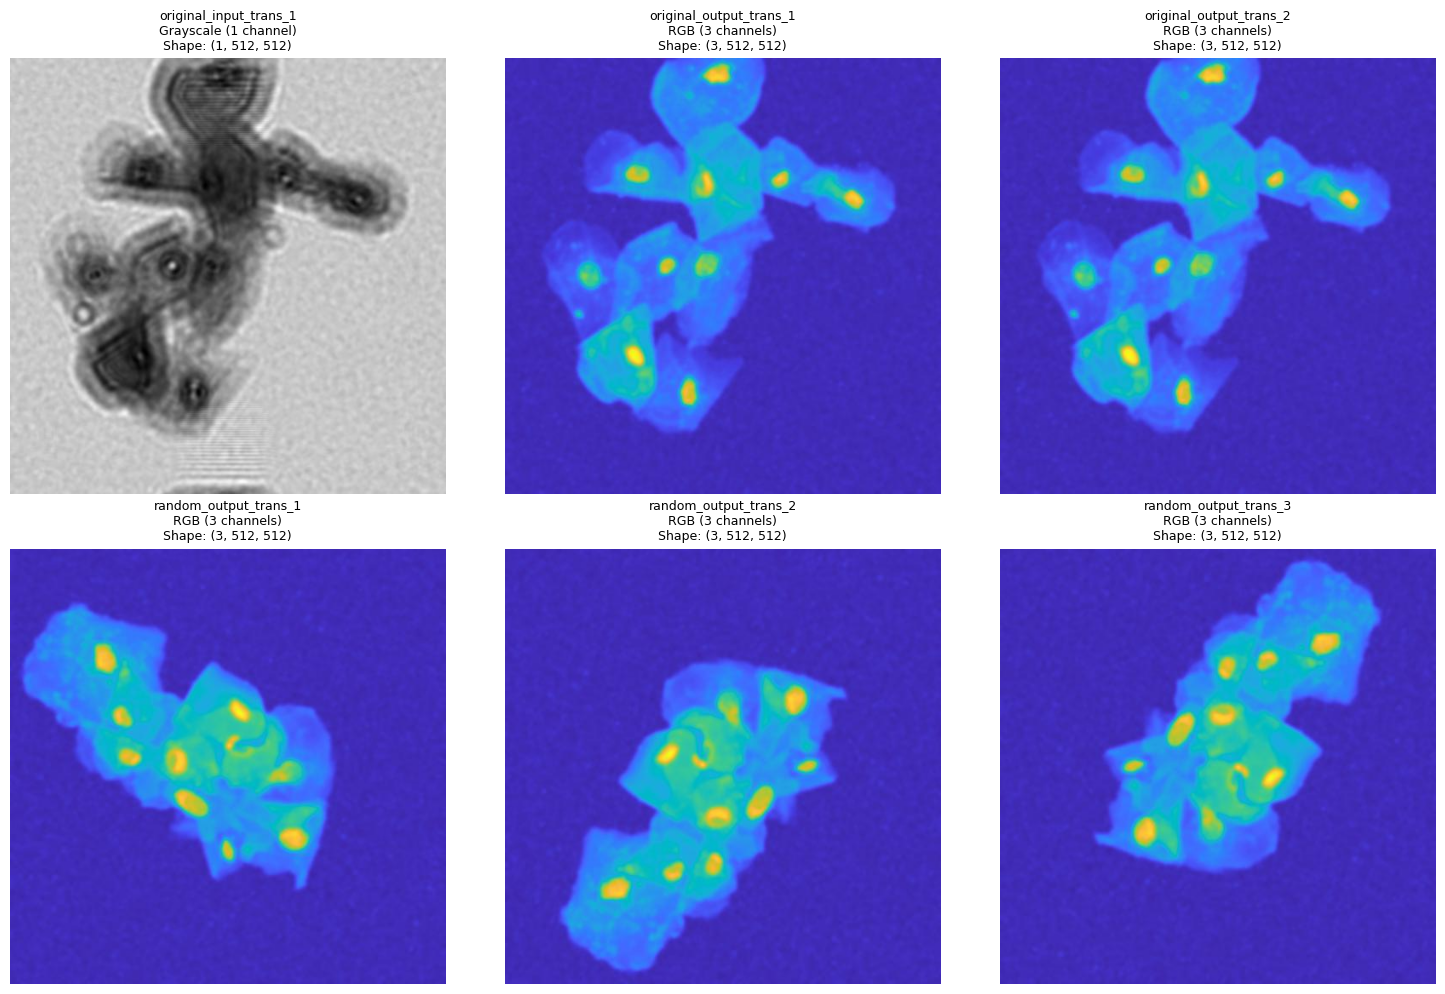


BATCH SUMMARY
Batch size: 4
Number of different image types: 6
Input (grayscale): ['original_input_trans_1']
Output (RGB): ['original_output_trans_1', 'original_output_trans_2', 'random_output_trans_1', 'random_output_trans_2', 'random_output_trans_3']


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Select which batch you want
k = 1

# Iterate over train_loader and pick kth batch
for i, batch in enumerate(train_loader, start=1):
    if i == k:
        selected_batch = batch
        break

# Print keys in selected batch
print(f"Keys in batch {k}:", selected_batch.keys())

# Print tensor details
for key, value in selected_batch.items():
    print(
        f"{key}: shape={value.shape}, dtype={value.dtype}, "
        f"min={value.min().item():.4f}, max={value.max().item():.4f}"
    )

print("\n" + "="*60)
print("VISUALIZING FIRST IMAGE FROM EACH TENSOR [0,:,:,:]")
print("="*60)

# Get all the keys
keys = list(selected_batch.keys())

# Calculate grid size for subplots
n_images = len(keys)
cols = 3
rows = (n_images + cols - 1) // cols  # Calculate rows needed

# Create figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

# Flatten axes array for easier indexing
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

# Plot each image
for idx, key in enumerate(keys):
    # Get the first image from the batch [0, :, :, :]
    img = selected_batch[key][0].cpu().numpy()  # Shape: (C, H, W)
    
    # Check if it's grayscale (1 channel) or RGB (3 channels)
    if img.shape[0] == 1:
        # Grayscale: shape is (1, H, W)
        img_display = img[0]  # Extract (H, W)
        axes[idx].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        channel_info = "Grayscale (1 channel)"
    else:
        # RGB: shape is (3, H, W), need to convert to (H, W, 3)
        img_display = np.transpose(img, (1, 2, 0))  # Convert to (H, W, 3)
        # Clip values to [0, 1] for display
        img_display = np.clip(img_display, 0, 1)
        axes[idx].imshow(img_display)
        channel_info = "RGB (3 channels)"
    
    # Set title with key name and shape
    axes[idx].set_title(f'{key}\n{channel_info}\nShape: {img.shape}', fontsize=9)
    axes[idx].axis('off')
    
    # Print some statistics
    print(f"{key}:")
    print(f"  Original shape: {img.shape}")
    print(f"  Channel info: {channel_info}")
    print(f"  Min: {img.min():.4f}, Max: {img.max():.4f}")
    print(f"  Mean: {img.mean():.4f}, Std: {img.std():.4f}")
    print()

# Hide unused subplots
for idx in range(len(keys), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("BATCH SUMMARY")
print("="*60)
print(f"Batch size: {selected_batch[keys[0]].shape[0]}")
print(f"Number of different image types: {len(keys)}")
print(f"Input (grayscale): {[k for k in keys if 'input' in k]}")
print(f"Output (RGB): {[k for k in keys if 'output' in k]}")

# Train Initializer

In [12]:

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

discriminator_model, optimizer_discriminator, scheduler_discriminator, criterion_gan = create_discriminator_and_optimizer(device=device)

# discriminator_model.to(device)

# Initialize models
unet_model = UNet(in_channels=1, out_channels=3).to(device)
siamese_net = SiameseNetwork(input_channels=3).to(device)
# discriminator_model = Discriminator(input_channels=3).to(device)

# Initialize optimizers
optimizer_unet = optim.Adam(unet_model.parameters(), lr=0.0005)
optimizer_siamese = optim.Adam(siamese_net.parameters(), lr=0.0005)
# optimizer_discriminator = optim.Adam(discriminator_model.parameters(), lr=0.0005)

scheduler_unet = CustomLRScheduler(optimizer=optimizer_unet,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)
scheduler_siamese = CustomLRScheduler(optimizer=optimizer_siamese,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)
# scheduler_discriminator = CustomLRScheduler(optimizer=optimizer_discriminator,start_lr=0.0005,end_lr=0.00001,decay_epochs=50)

# Initialize loss functions
bce_loss_siamese = nn.BCELoss()  # Siamese outputs probabilities
# bce_loss_discriminator = nn.BCEWithLogitsLoss()  # Discriminator outputs logits
# bce_loss_siamese = nn.MSELoss()  # Siamese outputs probabilities
# bce_loss_discriminator = nn.MSELoss()  # Discriminator outputs logits
l1_loss = nn.L1Loss()
mse_loss = nn.MSELoss()

# Training history
train_history = {
    'loss_unet': [],
    'loss_siamese': [],
    'loss_discriminator': [],
    'loss_total': [],
    'L1_loss': [],
    'MSE_loss': [],
    'unet_discriminator': [],
    'unet_siamese': []
}

val_history = { key: [] for key in train_history }

# Initialize best values very large
best_l1 = float("inf")
best_mse = float("inf")

best_l1_epoch = -1
best_mse_epoch = -1


Using device: cuda


# Train Items

In [13]:
# Training step example integrated with your framework
def train_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs list of predictions for multi-scale
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = criterion_gan(unet_adversarial_pred, target_is_real=True)
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = bce_loss_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 2.0 * loss_unet_similarity
    
    loss_unet_total.backward()
    torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = bce_loss_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = bce_loss_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = bce_loss_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = bce_loss_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim)
    
    loss_siamese_total.backward()
    torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training (Multi-Scale PatchGAN)
    # =============================================
    optimizer_discriminator.zero_grad()
    
    # Multi-scale discriminator outputs list of predictions
    real_pred = discriminator_model(original_output_trans_2)
    loss_discriminator_real = criterion_gan(real_pred, target_is_real=True)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    loss_discriminator_fake = criterion_gan(fake_pred, target_is_real=False)
    
    # Total discriminator loss
    loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) * 0.5
    
    loss_discriminator_total.backward()
    torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    optimizer_discriminator.step()
    
    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'loss_unet': loss_unet_total.item(),
        'loss_siamese': loss_siamese_total.item(),
        'loss_discriminator': loss_discriminator_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1_loss': loss_unet_l1.item(),
        'MSE_loss': loss_unet_mse.item(),
        'unet_discriminator': loss_unet_adversarial.item(),
        'unet_siamese': loss_unet_similarity.item()
    }

In [14]:
# Train for one epoch

def train_epoch(dataloader, epoch):
    """
    Train for one epoch
    """
    unet_model.train()
    siamese_net.train()
    discriminator_model.train()
    
    epoch_losses = {
        'loss_unet': 0,
        'loss_siamese': 0,
        'loss_discriminator': 0,
        'loss_total': 0,
        'L1_loss': 0,
        'MSE_loss': 0,
        'unet_discriminator': 0,
        'unet_siamese': 0
    }
    
    num_batches = len(dataloader)
    
    with tqdm(dataloader, desc=f'Epoch {epoch+1}') as pbar:
        for batch_idx, batch in enumerate(pbar):
            losses = train_step(batch)
            
            # Accumulate losses
            for key in epoch_losses:
                epoch_losses[key] += losses[key]
            
            # Update progress bar
            pbar.set_postfix({
                'U': f'{losses["loss_unet"]:.6f}',
                'S': f'{losses["loss_siamese"]:.6f}',
                'D': f'{losses["loss_discriminator"]:.6f}',
                'T': f'{losses["loss_total"]:.6f}',
                'L': f'{losses["L1_loss"]:.6f}',
                'M': f'{losses["MSE_loss"]:.6f}',
                'UD': f'{losses["unet_discriminator"]:.6f}',
                'US': f'{losses["unet_siamese"]:.6f}'
            })
    
    # Average losses for the epoch
    for key in epoch_losses:
        epoch_losses[key] /= num_batches
        train_history[key].append(epoch_losses[key])
    
    return epoch_losses


In [15]:
def validatin_step(batch):
    """
    Single training step for all models - optimized to avoid redundant UNet forward passes
    """
    # Extract batch data
    original_input_trans_1 = batch['original_input_trans_1'].to(device)
    original_output_trans_1 = batch['original_output_trans_1'].to(device)
    original_output_trans_2 = batch['original_output_trans_2'].to(device)
    random_output_trans_1 = batch['random_output_trans_1'].to(device)
    random_output_trans_2 = batch['random_output_trans_2'].to(device)
    random_output_trans_3 = batch['random_output_trans_3'].to(device)
    
    # =============================================
    # 1. UNet Training (with gradient tracking)
    # =============================================
    # optimizer_unet.zero_grad()
    
    # Single forward pass for UNet
    unet_output, att_map = unet_model(original_input_trans_1)
    
    # Reconstruction losses
    loss_unet_l1 = l1_loss(unet_output, original_output_trans_1)
    loss_unet_mse = mse_loss(unet_output, original_output_trans_1)
    
    # Adversarial loss - discriminator outputs list of predictions for multi-scale
    unet_adversarial_pred = discriminator_model(unet_output)
    loss_unet_adversarial = criterion_gan(unet_adversarial_pred, target_is_real=True)
    
    # Similarity loss - siamese outputs probabilities
    unet_siamese_similarity = siamese_net(unet_output, original_output_trans_2)
    unet_siamese_similarity_label = torch.zeros_like(unet_siamese_similarity)
    # Since siamese outputs probability of being dissimilar,
    # and we want UNet output to be similar to target, we minimize the similarity score
    loss_unet_similarity = bce_loss_siamese(unet_siamese_similarity, unet_siamese_similarity_label)
    
    # Combined UNet loss with weights
    loss_unet_total = 1.0 * loss_unet_adversarial + 2.0 * loss_unet_similarity
    
    # loss_unet_total.backward()
    # torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)
    # optimizer_unet.step()
    
    # =============================================
    # Save UNet output for reuse (detach from computation graph)
    # =============================================
    unet_output_detached = unet_output.detach()
    
    # =============================================
    # 2. Siamese Network Training 
    # ============================================= 
    # optimizer_siamese.zero_grad()
    
    # Siamese network outputs probabilities (has sigmoid)
    sim_similarity_1 = siamese_net(random_output_trans_1, random_output_trans_2)
    sim_labels_1 = torch.zeros_like(sim_similarity_1)
    
    sim_similarity_2 = siamese_net(random_output_trans_2, random_output_trans_3)
    sim_labels_2 = torch.zeros_like(sim_similarity_2)

    dissim_similarity = siamese_net(original_output_trans_2, random_output_trans_3)
    dissim_labels = torch.ones_like(dissim_similarity)

    # Use the saved detached UNet output
    unet_dissim_similarity = siamese_net(unet_output_detached, original_output_trans_2)
    unet_dissim_labels = torch.ones_like(unet_dissim_similarity)
    
    # Use BCELoss for siamese (outputs are probabilities)
    loss_siamese_sim_1 = bce_loss_siamese(sim_similarity_1, sim_labels_1)
    loss_siamese_sim_2 = bce_loss_siamese(sim_similarity_2, sim_labels_2)
    loss_siamese_dissim = bce_loss_siamese(dissim_similarity, dissim_labels)
    loss_siamese_unet_dissim = bce_loss_siamese(unet_dissim_similarity, unet_dissim_labels)
    
    loss_siamese_total = (loss_siamese_sim_1 + loss_siamese_sim_2 + 
                          loss_siamese_dissim + loss_siamese_unet_dissim)
    
    # loss_siamese_total.backward()
    # torch.nn.utils.clip_grad_norm_(siamese_net.parameters(), max_norm=1.0)
    # optimizer_siamese.step()
    
    # =============================================
    # 3. Discriminator Training (Multi-Scale PatchGAN)
    # =============================================
    # optimizer_discriminator.zero_grad()
    
    # Multi-scale discriminator outputs list of predictions
    real_pred = discriminator_model(original_output_trans_2)
    loss_discriminator_real = criterion_gan(real_pred, target_is_real=True)
    
    # Use the saved detached UNet output
    fake_pred = discriminator_model(unet_output_detached)
    loss_discriminator_fake = criterion_gan(fake_pred, target_is_real=False)
    
    # Total discriminator loss
    loss_discriminator_total = (loss_discriminator_real + loss_discriminator_fake) * 0.5
    
    # loss_discriminator_total.backward()
    # torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=1.0)
    # optimizer_discriminator.step()
    
    # =============================================
    # Return losses for logging
    # =============================================
    return {
        'loss_unet': loss_unet_total.item(),
        'loss_siamese': loss_siamese_total.item(),
        'loss_discriminator': loss_discriminator_total.item(),
        'loss_total': (loss_unet_total + loss_siamese_total + loss_discriminator_total).item(),
        'L1_loss': loss_unet_l1.item(),
        'MSE_loss': loss_unet_mse.item(),
        'unet_discriminator': loss_unet_adversarial.item(),
        'unet_siamese': loss_unet_similarity.item()
    }

In [16]:
@torch.no_grad()
def validate(val_dataloader):
    """
    Validation step
    """
    unet_model.eval()
    siamese_net.eval()
    discriminator_model.eval()
    
    val_losses = {
        'loss_unet': 0,
        'loss_siamese': 0,
        'loss_discriminator': 0,
        'loss_total': 0,
        'L1_loss': 0,
        'MSE_loss': 0,
        'unet_discriminator': 0,
        'unet_siamese': 0
    }
    
    num_batches = len(val_dataloader)
    
    for batch in tqdm(val_dataloader, desc='Validation'):
        losses = validatin_step(batch)  # Same forward pass, no gradients
        
        for key in val_losses:
            val_losses[key] += losses[key]
    
    # Average validation losses
    for key in val_losses:
        val_losses[key] /= num_batches
        val_history[key].append(val_losses[key])
    
    return val_losses

In [17]:
# Save Validation Images 

def save_validation_samples(val_dataloader, epoch, save_dir='validation_samples'):
    """
    Save validation samples:
    - One .npy file with input, UNet output, and ground truth
    - One comparison image with all samples as subplots
    """
    unet_model.eval()
    
    # Create directories
    image_dir = os.path.join(save_dir, 'images')
    numpy_dir = os.path.join(save_dir, 'numpy')
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(numpy_dir, exist_ok=True)
    
    with torch.no_grad():
        # Get first batch
        batch = next(iter(val_dataloader))
        
        # Extract data
        input_tensor = batch['original_input_trans_1'].to(device)  # Grayscale (B, 1, H, W)
        gt_tensor = batch['original_output_trans_1'].to(device)     # RGB (B, 3, H, W)
        
        # Forward pass
        output_tensor, att_map = unet_model(input_tensor)  # RGB output (B, 3, H, W)
        
        # Convert to numpy
        input_np = input_tensor.cpu().numpy()
        output_np = output_tensor.cpu().numpy()
        gt_np = gt_tensor.cpu().numpy()
        
        # Save numpy file (uncompressed)
        numpy_path = os.path.join(numpy_dir, f'epoch_{epoch+1}_validation_data.npy')
        np.save(numpy_path, {
            "input": input_np,
            "unet_output": output_np,
            "ground_truth": gt_np
        })
        # print(f"Saved numpy data: {numpy_path}")
        
        # Plot all samples in one figure
        batch_size = input_np.shape[0]
        fig, axes = plt.subplots(batch_size, 3, figsize=(12, 4 * batch_size))
        
        if batch_size == 1:  # make sure axes is 2D
            axes = np.expand_dims(axes, 0)
        
        # Normalize to [0, 1] range if needed
        def normalize(img):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                return (img - img_min) / (img_max - img_min)
            else:
                return img
        
        for i in range(batch_size):
            inp = input_np[i]   # Shape: (1, H, W) - grayscale
            out = output_np[i]  # Shape: (3, H, W) - RGB
            gt  = gt_np[i]      # Shape: (3, H, W) - RGB
            
            # Process input (grayscale)
            if inp.shape[0] == 1:  # (1, H, W) -> (H, W)
                inp_display = inp[0]
                inp_cmap = 'gray'
            else:
                inp_display = np.transpose(inp, (1, 2, 0))
                inp_cmap = None
            
            # Process UNet output (RGB)
            if out.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
                out_display = np.transpose(out, (1, 2, 0))
                out_cmap = None
            elif out.shape[0] == 1:  # In case output is grayscale
                out_display = out[0]
                out_cmap = 'gray'
            else:
                out_display = np.transpose(out, (1, 2, 0))
                out_cmap = None
            
            # Process ground truth (RGB)
            if gt.shape[0] == 3:  # (3, H, W) -> (H, W, 3)
                gt_display = np.transpose(gt, (1, 2, 0))
                gt_cmap = None
            elif gt.shape[0] == 1:  # In case GT is grayscale
                gt_display = gt[0]
                gt_cmap = 'gray'
            else:
                gt_display = np.transpose(gt, (1, 2, 0))
                gt_cmap = None
            
            # Normalize each image
            inp_display = normalize(inp_display)
            out_display = normalize(out_display)
            gt_display = normalize(gt_display)
            
            # Clip RGB images to [0, 1]
            if out_cmap is None:
                out_display = np.clip(out_display, 0, 1)
            if gt_cmap is None:
                gt_display = np.clip(gt_display, 0, 1)
            
            # Plot input (grayscale)
            axes[i, 0].imshow(inp_display, cmap=inp_cmap, vmin=0, vmax=1)
            axes[i, 0].set_title(f'Input (Grayscale)\nShape: {inp.shape}')
            axes[i, 0].axis('off')
            
            # Plot UNet output (RGB)
            axes[i, 1].imshow(out_display, cmap=out_cmap)
            axes[i, 1].set_title(f'UNet Output (RGB)\nShape: {out.shape}')
            axes[i, 1].axis('off')
            
            # Plot ground truth (RGB)
            axes[i, 2].imshow(gt_display, cmap=gt_cmap)
            axes[i, 2].set_title(f'Ground Truth (RGB)\nShape: {gt.shape}')
            axes[i, 2].axis('off')
        
        plt.tight_layout()
        comp_path = os.path.join(image_dir, f'epoch_{epoch+1}_comparison.png')
        plt.savefig(comp_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        # print(f"Saved comparison image: {comp_path}")
    
    # print(f"Validation samples saved for epoch {epoch+1}")

In [18]:
# plot training and validation losses

def plot_losses(save_dir):
    """
    Plot training and validation losses and save as PNGs.
    One combined plot + one per key.
    """
    os.makedirs(save_dir, exist_ok=True)

    print("Plotting losses...")
    
    # --- Combined plot ---
    plt.figure(figsize=(12, 8))
    for key in train_history.keys():
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Losses (All)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "all_losses.png"), dpi=150, bbox_inches="tight")
    plt.close()

    # --- Individual plots ---
    for key in train_history.keys():
        plt.figure(figsize=(8, 6))
        plt.plot(train_history[key], label=f"Train {key}")
        if len(val_history[key]) > 0:
            plt.plot(val_history[key], label=f"Val {key}")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Training and Validation Loss: {key}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{key}_loss.png"), dpi=150, bbox_inches="tight")
        plt.close()
    
    # print(f"Loss plots saved in {save_dir}")


In [19]:
# save weights function

def save_weights(epoch,num_epochs,save_dir='model_weights'):
    """
    Save last epoch weights and best validation weights.
    """
    global best_l1, best_mse, best_l1_epoch, best_mse_epoch
    os.makedirs(save_dir, exist_ok=True)

    # print(f"Saving weights at epoch {epoch+1}...")

    # --- Save best validation weights (based on L1_loss) ---
    current_val_L1 = val_history['L1_loss'][-1]  # last validation loss
    if current_val_L1 < best_l1:
        best_l1 = current_val_L1
        best_l1_epoch = epoch +1 
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_l1_epoch.pth"))
        print(f"✅ Best L1 Loss model updated at epoch {epoch+1} with val_loss={current_val_L1:.4f}")
        
    # --- Save best validation weights (based on MSE_loss) ---
    current_val_MSE = val_history['MSE_loss'][-1]  # last validation loss
    if current_val_MSE < best_mse:
        best_mse = current_val_MSE
        best_mse_epoch = epoch + 1
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "best_mse_epoch.pth"))
        print(f"✅ Best MSE Loss model updated at epoch {epoch+1} with val_loss={current_val_MSE:.4f}")
        
    # --- Save last epoch weights ---
    if (epoch + 1) == num_epochs:
        torch.save({
            'epoch': epoch+1,
            'unet': unet_model.state_dict(),
            'siamese': siamese_net.state_dict(),
            'discriminator': discriminator_model.state_dict(),
            'history_val': val_history,
            'history_train': train_history
        }, os.path.join(save_dir, "last_epoch.pth"))
        print(f"✅ Last epoch model saved at epoch {epoch+1}")
        
    
    # print(f"Weights saved in {save_dir}")    
    

# Train It

In [20]:
# Training parameters
num_epochs = 100
validate_every = 1  # Validate every N epochs
save_samples_every = 1  # Save validation samples every N epochs
save_dir = "../weaksup_Results/vw04_LDIHM_01_25jan"

print("Starting training...")
print(f"Total epochs: {num_epochs}")

for epoch in range(num_epochs):
    
    # Training
    train_losses = train_epoch(train_loader, epoch)
    print(
        f"UNet: {train_losses['loss_unet']:.6f} | "
        f"Siamese: {train_losses['loss_siamese']:.6f} | "
        f"Discriminator: {train_losses['loss_discriminator']:.6f} | "
        f"Total: {train_losses['loss_total']:.6f} | "
        f"L1: {train_losses['L1_loss']:.6f} | "
        f"MSE: {train_losses['MSE_loss']:.6f}"
    )
    # Validation
    val_losses = validate(val_loader)
    print(
        f"UNet: {val_losses['loss_unet']:.6f} | "
        f"Siamese: {val_losses['loss_siamese']:.6f} | "
        f"Discriminator: {val_losses['loss_discriminator']:.6f} | "
        f"Total: {val_losses['loss_total']:.6f} | "
        f"L1: {val_losses['L1_loss']:.6f} | "
        f"MSE: {val_losses['MSE_loss']:.6f}"
    )
            
    # save validation images
    if (epoch + 1) % save_samples_every == 0:
        save_validation_samples(val_loader, epoch, save_dir=save_dir)
        
    # Plot losses
    plot_losses(save_dir=save_dir)
    
    # Save weights
    save_weights(epoch,num_epochs, save_dir=save_dir)
    
    print(f"best_l1: {best_l1:.4f} at epoch {best_l1_epoch} | best_mse: {best_mse:.4f} at epoch {best_mse_epoch}")

    scheduler_unet.step()
    scheduler_siamese.step()
    scheduler_discriminator.step()

    lr_unet = optimizer_unet.param_groups[0]['lr']
    lr_siamese = optimizer_siamese.param_groups[0]['lr']
    lr_discriminator = optimizer_discriminator.param_groups[0]['lr']
    
    print(f" Learning Rates -> UNet: {lr_unet:.6f}, Siamese: {lr_siamese:.6f}, Discriminator: {lr_discriminator:.6f}")

    print("-" * 150)

print("Training completed!")


Starting training...
Total epochs: 100


Epoch 1: 100%|██████████| 328/328 [01:44<00:00,  3.14it/s, U=18.399397, S=1.431853, D=0.129346, T=19.960596, L=0.176658, M=0.049670, UD=1.337988, US=8.530704]   


UNet: 20.332817 | Siamese: 2.527695 | Discriminator: 0.169759 | Total: 23.030272 | L1: 0.222596 | MSE: 0.078412


Validation: 100%|██████████| 110/110 [00:15<00:00,  6.88it/s]


UNet: 142.581702 | Siamese: 1.766003 | Discriminator: 0.068029 | Total: 144.415733 | L1: 0.175006 | MSE: 0.043897
Plotting losses...
✅ Best L1 Loss model updated at epoch 1 with val_loss=0.1750
✅ Best MSE Loss model updated at epoch 1 with val_loss=0.0439
best_l1: 0.1750 at epoch 1 | best_mse: 0.0439 at epoch 1
 Learning Rates -> UNet: 0.000490, Siamese: 0.000490, Discriminator: 0.000199
------------------------------------------------------------------------------------------------------------------------------------------------------


...

UNet: 47.016196 | Siamese: 1.234740 | Discriminator: 0.001526 | Total: 48.252462 | L1: 0.157743 | MSE: 0.042050


Validation: 100%|██████████| 110/110 [00:19<00:00,  5.77it/s]


UNet: 18.590752 | Siamese: 1.378488 | Discriminator: 0.000333 | Total: 19.969572 | L1: 0.216132 | MSE: 0.078645
Plotting losses...
best_l1: 0.0957 at epoch 7 | best_mse: 0.0215 at epoch 7
 Learning Rates -> UNet: 0.000343, Siamese: 0.000343, Discriminator: 0.000184
------------------------------------------------------------------------------------------------------------------------------------------------------


Epoch 17:  71%|███████   | 233/328 [01:14<00:30,  3.13it/s, U=52.612095, S=1.267590, D=0.000499, T=53.880184, L=0.206898, M=0.066580, UD=1.004640, US=25.803728]  


KeyboardInterrupt: 